<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/dmd_nikkei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import math
import statistics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
from scipy.linalg import svd
import warnings

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

In [ ]:
#ticker_code = '^N225'
ticker_code = 'NG=F'
# Tickerオブジェクトを作成
nikkei = yf.Ticker(ticker_code)
y_df = nikkei.history(start='2018-01-01', end='2026-07-13')

In [ ]:
y_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-01-02 00:00:00-05:00,3.030,3.097,2.923,3.056,320176,0.0,0.0
2018-01-03 00:00:00-05:00,3.040,3.056,2.959,3.008,269889,0.0,0.0
2018-01-04 00:00:00-05:00,3.015,3.070,2.840,2.880,319705,0.0,0.0
2018-01-05 00:00:00-05:00,2.877,2.887,2.746,2.795,230946,0.0,0.0
2018-01-08 00:00:00-05:00,2.812,2.869,2.784,2.835,228242,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-06 00:00:00-04:00,3.206,3.256,3.159,3.245,205853,0.0,0.0
2026-07-07 00:00:00-04:00,3.254,3.320,3.181,3.265,172662,0.0,0.0
2026-07-08 00:00:00-04:00,3.281,3.355,3.203,3.212,158732,0.0,0.0


In [ ]:
y_df = y_df.drop('High',axis=1)
y_df = y_df.drop('Low',axis=1)
y_df = y_df.drop('Volume',axis=1)
y_df = y_df.drop('Dividends',axis=1)
y_df = y_df.drop('Stock Splits',axis=1)
y_df

,Open,Close
Date,,
2018-01-02 00:00:00-05:00,3.030,3.056
2018-01-03 00:00:00-05:00,3.040,3.008
2018-01-04 00:00:00-05:00,3.015,2.880
2018-01-05 00:00:00-05:00,2.877,2.795
2018-01-08 00:00:00-05:00,2.812,2.835
...,...,...
2026-07-06 00:00:00-04:00,3.206,3.245
2026-07-07 00:00:00-04:00,3.254,3.265
2026-07-08 00:00:00-04:00,3.281,3.212


<Axes: xlabel='Date'>

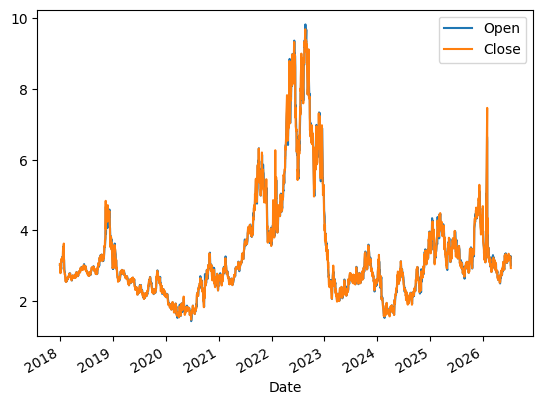

In [ ]:
y_df.plot()

In [ ]:


class DynamicModeDecomposition:
    def __init__(self, rank=None, svd_rank=None,T=None):
        """
        動的モード分解（DMD）クラス
        論文 "Dynamic mode decomposition of numerical and experimental data" に基づく実装

        Parameters:
        rank: DMDで使用するランク（Noneの場合は自動決定）
        svd_rank: SVDで使用するランク（Noneの場合は自動決定）
        """
        self.rank = rank
        self.svd_rank = svd_rank
        self.modes = None
        self.eigenvalues = None
        self.amplitudes = None
        self.Phi = None  # DMDモード
        self.omega = None  # 連続時間固有値
        self.b = None  # 初期振幅
        self.A_tilde = None  # 低次元線形演算子
        self.T = T

    def fit(self, X, dt=1.0):
        """
        DMDアルゴリズムを実行

        Parameters:
        X: データ行列 (n_features x n_timesteps)
        dt: 時間刻み
        """
        # Step 1: データをX1とX2に分割
        X1 = X[:, :-1]  # x_1, x_2, ..., x_{m-1}
        X2 = X[:, 1:]   # x_2, x_3, ..., x_m

        # Step 2: X1のSVD分解
        U, s, Vt = svd(X1, full_matrices=False)

        # Step 3: ランクの決定とtruncation
        if self.svd_rank is None:
            # 特異値の閾値による自動ランク決定
            tolerance = 1e-10
            self.svd_rank = np.sum(s > tolerance)

        r = min(self.svd_rank, len(s))
        U_r = U[:, :r]
        s_r = s[:r]
        V_r = Vt[:r, :].T

        # Step 4: 低次元線形演算子A_tildeの計算
        self.A_tilde = U_r.T @ X2 @ V_r @ np.diag(1/s_r)
        #self.A_tilde = U_r.T @ X2 @ V_r @ np.linalg.pinv(s_r)

        # Step 5: A_tildeの固有値分解
        eigenvals, W = np.linalg.eig(self.A_tilde)

        # Step 6: DMDモードの計算
        self.Phi = X2 @ V_r @ np.diag(1/s_r) @ W
        #self.Phi = X2 @ V_r @ np.linalg.pinv(s_r) @ W

        # 離散時間固有値
        self.eigenvalues = eigenvals

        # 連続時間固有値（論文の式に基づく）
        #self.omega = np.log(eigenvals) / dt
        self.omega = eigenvals #dt=1の場合 expがpredictのところで入れていないためlog入れていない

        # Step 7: 初期振幅の計算
        self.b = np.linalg.pinv(self.Phi) @ X[:, 0]

        # 使用するモード数の決定
        if self.rank is None:
            self.rank = r
        else:
            self.rank = min(self.rank, r)

        return self

    def predict(self, t_eval, x0=None):
        """
        指定された時刻での状態を予測

        Parameters:
        t_eval: 評価時刻
        x0: 初期条件（Noneの場合は学習データの初期条件を使用）

        Returns:
        X_pred: 予測された状態 (n_features )
        """
        if self.Phi is None:
            raise ValueError("まずfit()を実行してください")

        if x0 is not None:
            # 新しい初期条件での振幅計算
            b = np.linalg.pinv(self.Phi) @ x0
        else:
            b = self.b
        t_ = self.T + t_eval

        # 時間発展の計算
        # x(t) = Φ * diag(b) * exp(ω*t)

        time_evolution = np.array(self.omega[:self.rank, np.newaxis] **t_)

        # 予測
        X_pred = self.Phi[:, :self.rank] @ (b[:self.rank, np.newaxis] * time_evolution)

        return X_pred

    def compute_dmd_solution(self, t_eval, mode_indices=None):
        """
        特定のモードのみを使用したDMD解を計算

        Parameters:
        t_eval: 評価時刻
        mode_indices: 使用するモードのインデックス（Noneの場合は全モード）
        """
        if mode_indices is None:
            mode_indices = range(self.rank)

        time_evolution = np.exp(np.outer(self.omega[mode_indices], t_eval))
        X_dmd = self.Phi[:, mode_indices] @ (self.b[mode_indices, np.newaxis] * time_evolution)

        return X_dmd

In [ ]:
#15～40用
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp

magic_num = 5 #90
estimate_num = 150
predict_time = 1

df_array = y_df.to_numpy()


for i in range(1,17):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  predict_flag2 = 0
  for j in range(magic_num-1,len(df_array)):
    X_return_list = []
    for k in range(1,magic_num):
      X_return_list.append(df_array[j-k])
    y_return = np.log(df_array[j]/df_array[j-1])
    current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_return_list))
    total_list.append(X_list2)

  total_list = np.array(total_list)
  y_list = np.array(y_list)
  current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j)
    X_array = np.array(total_list[j])
    y_array = y_list[j]
    current_X = np.array(current_list[j])
    #print(X_array.shape)
    #print(y_array.shape)
    #print("#")

    #この後Xを転置してDMDに突っ込む
    X_DMD = X_array.T
    dmd = DynamicModeDecomposition(rank=15, svd_rank=1,T=magic_num)

    dmd.fit(X_DMD)
    X_pred = dmd.predict(predict_time)
    #print(X_pred.real)

    y_pred = X_pred[1,0].real
    #print(y_pred
    current_y = current_X[1]
    retrun_ = y_array[1]
    #print(current_y)

    if y_pred - current_y >= 0.0000:
      predict_flag = 1
    elif y_pred - current_y <-0.0000:
      predict_flag = -1
    else:
      predict_flag = predict_flag2

    if predict_flag*predict_flag2 >=0:
      result_r = retrun_*predict_flag
      result_list.append(result_r)
      predict_flag2 = predict_flag
    else:
      result_r = retrun_*predict_flag-0.00
      result_list.append(result_r)
      predict_flag2 = predict_flag
      #print("change_point:",j)

  R_sum = sum(result_list)
  SR = np.mean(np.array(result_list))/np.std(np.array(result_list))
  print("SharpRatio:",SR)
  print(R_sum)


100
SharpRatio: 0.14794570315888092
0.2588932493333955
200
SharpRatio: 0.07365446622438697
0.2845127456758251
300
SharpRatio: 0.059942011739060594
0.30821935071921136
400
SharpRatio: 0.04302479848949659
0.2757044974869536
500
SharpRatio: 0.03735858511205799
0.28022660221147655
600
SharpRatio: 0.04349855190759601
0.37235311384878966
700
SharpRatio: 0.05221450570981573
0.495723056259022
800
SharpRatio: 0.04690089980599772
0.4834463613965595
900
SharpRatio: 0.034947430839868794
0.39575487577160773
1000
SharpRatio: 0.0275600995949025
0.33948292702479355
1100
SharpRatio: 0.03637558828191108
0.4857176284139787
1200
SharpRatio: 0.03386084715396024
0.48248039152909783
1300
SharpRatio: 0.029917066213182547
0.4541225971922387
1400
SharpRatio: 0.02946549749417492
0.4777513659846643
1500
SharpRatio: 0.03210605755227712
0.5610983163947713
1600
SharpRatio: 0.03207712151660875
0.6136741408953125


In [ ]:
#移動平均考慮バージョン
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp

magic_num = 5 #90
estimate_num = 150
mean_num = 5
predict_time = 1

df_array = y_df.to_numpy()


for i in range(1,17):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  predict_flag = 0
  predict_flag2 = 0
  change_num = 0
  for j in range(magic_num-1,len(df_array)):
    X_return_list = []
    for k in range(1,magic_num):
      X_return_list.append(df_array[j-k])
    y_return = np.log(df_array[j]/df_array[j-1])
    current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_return_list))
    total_list.append(X_list2)

  total_list = np.array(total_list)
  y_list = np.array(y_list)
  current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j+magic_num-1)
    X_array = np.array(total_list[j])
    #print(X_array)
    mean_list = []
    for l in range(len(X_array)-mean_num,len(X_array)):
      mean_list.append(X_array[l][1])#二番目を変える

    y_array = y_list[j]
    current_X = np.array(current_list[j])
    mean_X = np.mean(np.array(mean_list))
    #print(mean_list)
    #print(mean_X)
    #print(X_array.shape)
    #print(y_array.shape)
    #print("#")

    #この後Xを転置してDMDに突っ込む
    X_DMD = X_array.T
    dmd = DynamicModeDecomposition(rank=15, svd_rank=1,T=magic_num)

    dmd.fit(X_DMD)
    X_pred = dmd.predict(predict_time)
    #print(X_pred.real)

    y_pred = X_pred[1,0].real
    #print(y_pred
    current_y = current_X[1]
    retrun_ = y_array[1]
    #print(current_y)

    if y_pred - current_y >= 0.0000:
      if mean_X > current_y:
        predict_flag = 1 #-1
    elif y_pred - current_y <-0.0000:
      if mean_X < current_y:
        predict_flag = -1
    else:
      predict_flag = 0

    if predict_flag==predict_flag2:
      result_r = retrun_*predict_flag
      result_list.append(result_r)
      predict_flag2 = predict_flag
    else:
      result_r = retrun_*predict_flag-0.00
      result_list.append(result_r)
      predict_flag2 = predict_flag
      change_num +=1
      #print("change_point:",j)

  R_sum = sum(result_list)
  SR = np.mean(np.array(result_list))/np.std(np.array(result_list))
  print("SharpRatio:",SR)
  print(R_sum)
  print("change_num:",change_num)

100
SharpRatio: 0.1384855061204094
0.39277713619190513
change_num: 28
200
SharpRatio: 0.006027893553065072
0.08473295169124709
change_num: 46
300
SharpRatio: 0.0277794070036334
0.5083273223434016
change_num: 67
400
SharpRatio: 0.04758783641575735
1.1090167421745374
change_num: 82
500
SharpRatio: 0.05307002942130354
1.4820355425480392
change_num: 100
600
SharpRatio: 0.05551583410745574
1.8111227644603756
change_num: 113
700
SharpRatio: 0.050072143051070175
1.8581658788621493
change_num: 127
800
SharpRatio: 0.04284473821195692
1.7568594889132152
change_num: 150
900
SharpRatio: 0.05470140613607167
2.5626037890183615
change_num: 171
1000
SharpRatio: 0.0474253054958764
2.461801263686455
change_num: 186
1100
SharpRatio: 0.03705347639879847
2.1283283902636723
change_num: 204
1200
SharpRatio: 0.023242967818183406
1.5148558464492052
change_num: 226
1300
SharpRatio: 0.023289551838991732
1.5968857064590063
change_num: 247
1400
SharpRatio: 0.024577345515783097
1.7689458171053705
change_num: 267
15